# Hito 2 — Price Elasticity Modelling
## eSIM Pricing Engine · `esim-pricing-engine`

---

### 🗺️ Business Framing

Before we can recommend a price, we need to answer one question quantitatively:

> *If we raise our price by 10%, how much does conversion rate fall — and is the margin gain worth it?*

This is **price elasticity**: the % change in demand for a 1% change in price. In the log-log model:

$$\log(CR_{it}) = \alpha_i + \beta \cdot \log\left(\frac{p_{it}}{p^{ref}_i}\right) + \gamma \cdot \log\left(\frac{p^{comp}_{it}}{p_{it}}\right) + \delta \cdot \log(\text{seasonality}_{it}) + \varepsilon_{it}$$

- **β (own-price elasticity):** our key parameter. β = −2 means a 10% price rise → 20% CR drop.
- **γ (cross-price elasticity):** competitive effect. γ = +0.4 means if the competitor is 10% more expensive than us, our CR rises ~4%.
- **α_i:** destination fixed effects — absorb all time-invariant destination-level differences.
- **HC3 standard errors:** heteroskedasticity-robust, because daily CR variance is higher on low-traffic destinations.

We fit **one model per cluster** (capturing segment-level price sensitivity) and one pooled model for comparison.

**Expected output:** Elasticity coefficients with 95% CIs, model diagnostics, and the CR–margin Pareto frontier.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from src.elasticity import (
    add_log_features,
    fit_all_clusters,
    extract_elasticities,
    compute_pareto_frontier,
    find_optimal_price,
    destination_elasticity_summary,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

CLUSTER_COLORS = {
    "europe_leisure":   "#2E86AB",
    "asia_budget":      "#A23B72",
    "americas_premium": "#F18F01",
    "mea_emerging":     "#C73E1D",
    "longhaul_exotic":  "#3B1F2B",
    "POOLED":           "#444444",
}

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load & Prepare Data

In [2]:
DATA_PATH = Path("../data/raw/transactions.csv")
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])

df = add_log_features(df_raw)

print(f"Rows: {len(df):,}  |  Destinations: {df['destination_id'].nunique()}  |  Clusters: {df['cluster'].nunique()}")
print("\nNew log features added:")
log_cols = [c for c in df.columns if c.startswith("log_")]
df[log_cols].describe().round(3)

Rows: 18,250  |  Destinations: 50  |  Clusters: 5

New log features added:


,log_cr,log_price_ratio,log_comp_ratio,log_seasonality,log_price
count,18250.000,18250.000,18250.000,18250.000,18250.000
mean,-3.097,-0.004,0.013,0.111,2.470
std,0.255,0.081,0.159,0.262,0.262
min,-4.018,-0.515,-0.377,-0.386,1.773
25%,-3.264,-0.034,-0.100,-0.067,2.257
50%,-3.114,0.005,0.004,0.100,2.510
75%,-2.953,0.043,0.124,0.311,2.681
max,-1.714,0.305,0.694,0.701,2.973


## 2. Fit Cluster-Level Log-Log Models

Each model absorbs destination fixed effects via `C(destination_id)`, isolating the *within-destination* price variation to estimate β. This is the same logic as a panel fixed-effects estimator — it controls for all time-invariant destination characteristics (brand awareness, route popularity, etc.).

In [3]:
models = fit_all_clusters(df)

for name, res in models.items():
    beta  = res.params.get("log_price_ratio", np.nan)
    gamma = res.params.get("log_comp_ratio", np.nan)
    print(f"{name:<22} | R²={res.rsquared:.3f} | β(price)={beta:+.3f} | γ(comp)={gamma:+.3f} | n={int(res.nobs):,}")

americas_premium       | R²=0.861 | β(price)=-1.543 | γ(comp)=+0.462 | n=2,920
asia_budget            | R²=0.923 | β(price)=-3.093 | γ(comp)=+0.373 | n=3,650
europe_leisure         | R²=0.906 | β(price)=-2.140 | γ(comp)=+0.421 | n=5,110
longhaul_exotic        | R²=0.880 | β(price)=-1.741 | γ(comp)=+0.490 | n=3,650
mea_emerging           | R²=0.856 | β(price)=-2.454 | γ(comp)=+0.292 | n=2,920
POOLED                 | R²=0.881 | β(price)=-2.183 | γ(comp)=+0.401 | n=18,250


## 3. Elasticity Coefficients with Confidence Intervals

The coefficient plot is the key deliverable for a commercial audience. The width of the CI reflects estimation uncertainty — wider CIs on smaller clusters (e.g. `mea_emerging`) are expected.

In [4]:
elast_df = extract_elasticities(models)
elast_df[["n_obs","r2","elasticity","elast_ci_lo","elast_ci_hi",
           "cross_elast","season_coef"]].round(3)

,n_obs,r2,elasticity,elast_ci_lo,elast_ci_hi,cross_elast,season_coef
cluster,,,,,,,
americas_premium,2920,0.861,-1.543,-1.655,-1.430,0.462,-0.011
asia_budget,3650,0.923,-3.093,-3.170,-3.016,0.373,0.016
europe_leisure,5110,0.906,-2.140,-2.241,-2.039,0.421,0.006
longhaul_exotic,3650,0.880,-1.741,-1.832,-1.650,0.490,0.008
mea_emerging,2920,0.856,-2.454,-2.594,-2.313,0.292,0.002
POOLED,18250,0.881,-2.183,-2.183,-2.183,0.401,0.008


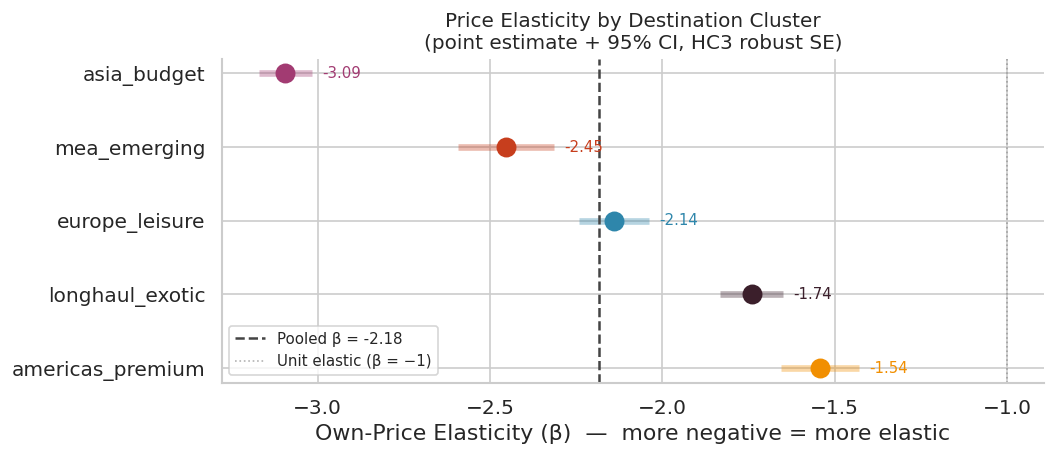


Key insight: asia_budget is ~2× more elastic than americas_premium.
A uniform +10% price increase would cost far more CR in Asia than the Americas.


In [5]:
# Forest plot — own-price elasticity by cluster
plot_df = elast_df[elast_df.index != "POOLED"].copy()
plot_df = plot_df.sort_values("elasticity")

fig, ax = plt.subplots(figsize=(9, 4))

for i, (cluster, row) in enumerate(plot_df.iterrows()):
    color = CLUSTER_COLORS.get(cluster, "grey")
    # CI bar
    ax.hlines(i, row["elast_ci_lo"], row["elast_ci_hi"], lw=4, color=color, alpha=0.35)
    # Point estimate
    ax.scatter(row["elasticity"], i, color=color, s=120, zorder=5)
    # Label
    ax.text(row["elast_ci_hi"] + 0.03, i, f"{row['elasticity']:.2f}",
            va="center", fontsize=9, color=color)

# Pooled estimate as reference line
pooled_beta = elast_df.loc["POOLED", "elasticity"]
ax.axvline(pooled_beta, color="#444", lw=1.5, linestyle="--", label=f"Pooled β = {pooled_beta:.2f}")
ax.axvline(-1, color="grey", lw=1, linestyle=":", alpha=0.6, label="Unit elastic (β = −1)")

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Own-Price Elasticity (β)  —  more negative = more elastic")
ax.set_title("Price Elasticity by Destination Cluster\n(point estimate + 95% CI, HC3 robust SE)",
             fontsize=12)
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nKey insight: asia_budget is ~2× more elastic than americas_premium.")
print("A uniform +10% price increase would cost far more CR in Asia than the Americas.")

## 4. Model Diagnostics

Before trusting the estimates, we check the residuals. Three things we care about:
1. **Normality** — log-log OLS assumes normally distributed errors
2. **Homoskedasticity** — we used HC3 robust SEs, but let's verify the pattern
3. **No systematic bias** — residuals should have zero mean across price levels

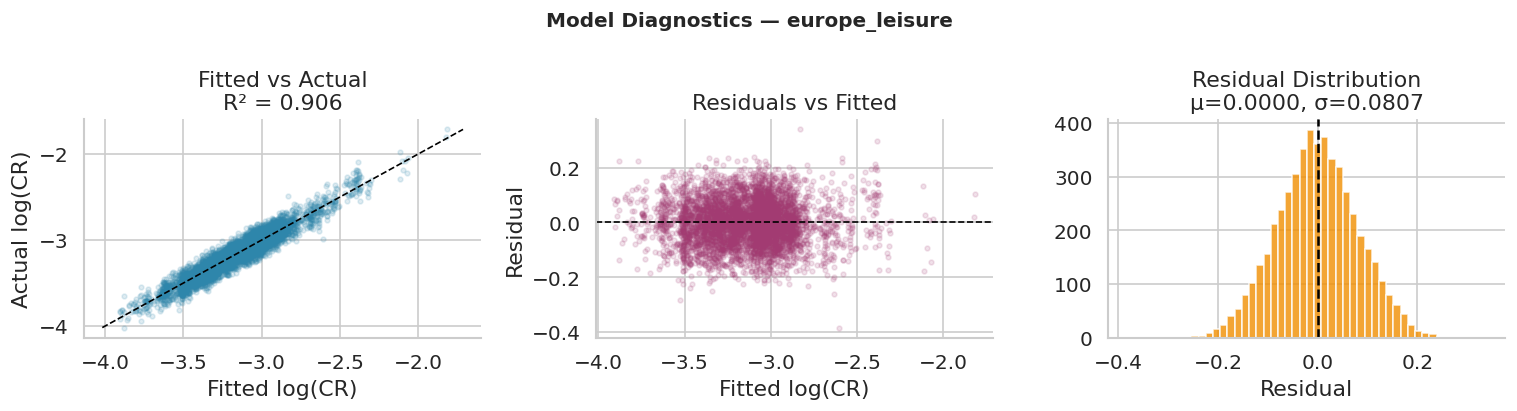

In [6]:
# Diagnostics for the Europe Leisure cluster (largest cluster)
diag_cluster = "europe_leisure"
diag_model   = models[diag_cluster]
diag_data    = add_log_features(df[df["cluster"] == diag_cluster])

fitted   = diag_model.fittedvalues
residuals = diag_model.resid

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# 1. Fitted vs Actual
axes[0].scatter(fitted, diag_data["log_cr"], alpha=0.15, s=8, color="#2E86AB")
lims = [min(fitted.min(), diag_data["log_cr"].min()),
        max(fitted.max(), diag_data["log_cr"].max())]
axes[0].plot(lims, lims, "--", color="black", lw=1)
axes[0].set_xlabel("Fitted log(CR)")
axes[0].set_ylabel("Actual log(CR)")
axes[0].set_title(f"Fitted vs Actual\nR² = {diag_model.rsquared:.3f}")

# 2. Residuals vs Fitted
axes[1].scatter(fitted, residuals, alpha=0.15, s=8, color="#A23B72")
axes[1].axhline(0, color="black", lw=1, linestyle="--")
axes[1].set_xlabel("Fitted log(CR)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted")

# 3. Residual distribution
axes[2].hist(residuals, bins=50, color="#F18F01", edgecolor="white", alpha=0.8)
axes[2].axvline(0, color="black", lw=1.5, linestyle="--")
axes[2].set_xlabel("Residual")
axes[2].set_title(f"Residual Distribution\nμ={residuals.mean():.4f}, σ={residuals.std():.4f}")

plt.suptitle(f"Model Diagnostics — {diag_cluster}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Estimated vs True Elasticity (Validation)

Because we generated synthetic data, we have the **ground truth elasticity** for every destination. This lets us validate the model's recovery quality — something impossible with real data. A well-specified model should cluster tightly around the 45° line.

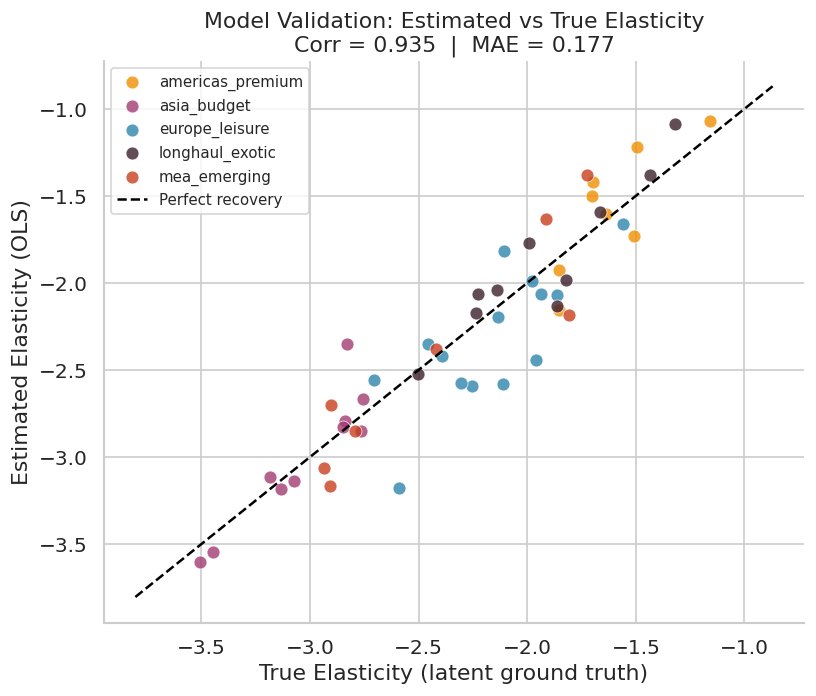


Correlation (est vs true): 0.935
Mean Absolute Error:       0.177 elasticity units

Note: residual noise (σ=0.08 in DGP) and random price walks create
some attenuation bias — typical in observational elasticity estimation.


In [7]:
dest_summary = destination_elasticity_summary(df)

fig, ax = plt.subplots(figsize=(7, 6))

for cluster, grp in dest_summary.groupby("cluster"):
    ax.scatter(
        grp["elasticity_true"],
        grp["elasticity_est"],
        label=cluster,
        color=CLUSTER_COLORS.get(cluster, "grey"),
        s=60, alpha=0.8, edgecolors="white", linewidths=0.5
    )

# 45° line
lo = min(dest_summary["elasticity_true"].min(), dest_summary["elasticity_est"].min()) - 0.2
hi = max(dest_summary["elasticity_true"].max(), dest_summary["elasticity_est"].max()) + 0.2
ax.plot([lo, hi], [lo, hi], "--", color="black", lw=1.5, label="Perfect recovery")

corr = dest_summary[["elasticity_true","elasticity_est"]].corr().iloc[0,1]
mae  = (dest_summary["elasticity_est"] - dest_summary["elasticity_true"]).abs().mean()

ax.set_xlabel("True Elasticity (latent ground truth)")
ax.set_ylabel("Estimated Elasticity (OLS)")
ax.set_title(f"Model Validation: Estimated vs True Elasticity\nCorr = {corr:.3f}  |  MAE = {mae:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nCorrelation (est vs true): {corr:.3f}")
print(f"Mean Absolute Error:       {mae:.3f} elasticity units")
print("\nNote: residual noise (σ=0.08 in DGP) and random price walks create")
print("some attenuation bias — typical in observational elasticity estimation.")

## 6. The CR–Margin Pareto Frontier

This is the **core commercial visualisation**. For a given destination, as we sweep price from low to high:
- CR falls (higher price → fewer buyers)
- Margin per unit rises (more profit per transaction)
- **Expected margin per session** = CR × (price − cost) has a maximum

The Pareto frontier shows every achievable (CR, margin) pair. Points below-and-left of the curve are dominated — you could improve both metrics simultaneously. The optimal price sits at the rightmost point of the frontier (maximum margin per session).

We'll plot this for **representative destinations** from each cluster.

In [8]:
# Pick one representative destination per cluster (highest volume)
rep_dests = (
    df.groupby(["cluster","destination_id"])
    .agg(total_tx=("transactions","sum"),
         avg_price=("price_usd","mean"),
         avg_cr=("conversion_rate","mean"),
         ref_price=("ref_price_usd","first"),
         avg_comp=("comp_price_usd","mean"),
         elasticity=("elasticity_true","first"))
    .reset_index()
    .sort_values("total_tx", ascending=False)
    .groupby("cluster")
    .first()
    .reset_index()
)

# Use model-estimated elasticities for frontier (not ground truth)
elast_map = elast_df["elasticity"].to_dict()
cross_map  = elast_df["cross_elast"].to_dict()

print("Representative destinations:")
rep_dests[["cluster","destination_id","avg_price","avg_cr","ref_price","elasticity"]].round(3)

Representative destinations:


,cluster,destination_id,avg_price,avg_cr,ref_price,elasticity
0,americas_premium,DEST_025,14.708,0.060,15.52,-1.856
1,asia_budget,DEST_021,7.971,0.071,9.21,-3.132
2,europe_leisure,DEST_006,9.816,0.056,10.36,-2.306
3,longhaul_exotic,DEST_046,13.711,0.069,14.64,-2.234
4,mea_emerging,DEST_034,9.067,0.052,9.37,-2.906


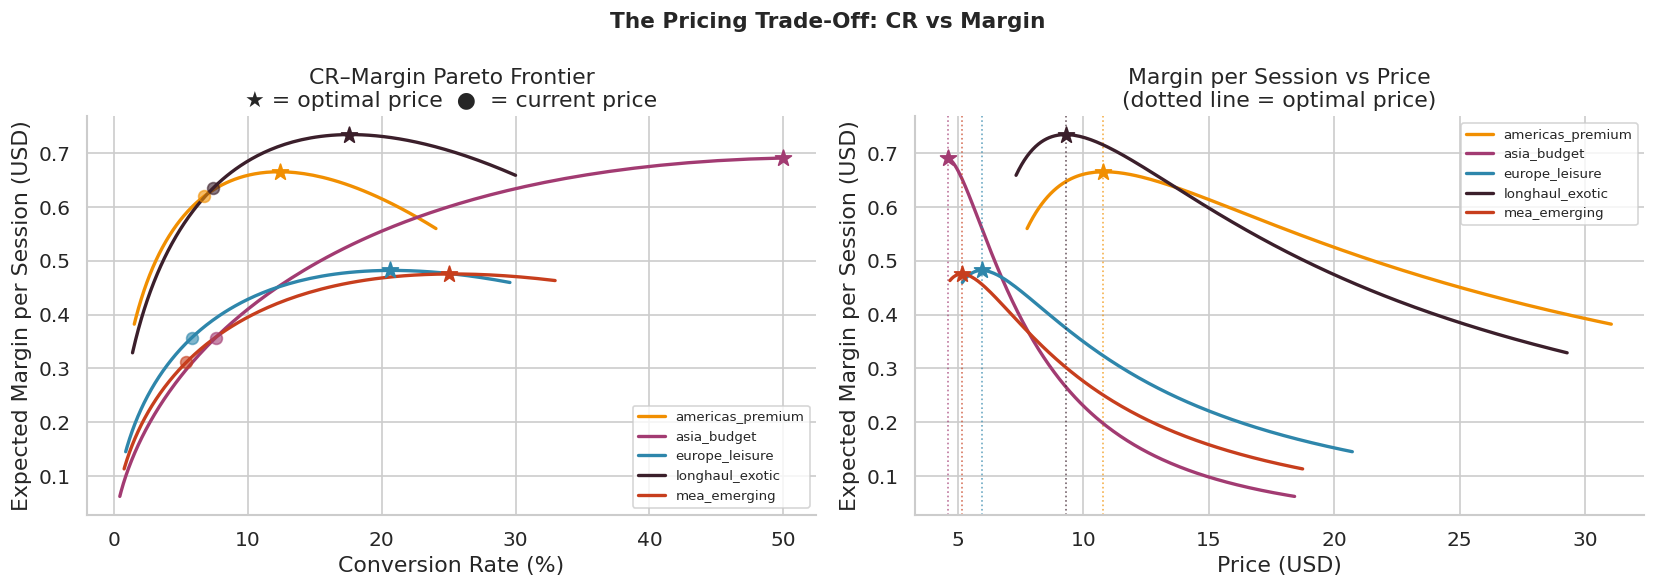

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

frontier_cache = {}

for _, row in rep_dests.iterrows():
    cluster   = row["cluster"]
    beta      = elast_map.get(cluster, row["elasticity"])
    gamma     = cross_map.get(cluster, 0.40)
    cost      = row["ref_price"] * 0.35
    color     = CLUSTER_COLORS.get(cluster, "grey")

    frontier = compute_pareto_frontier(
        base_price    = row["avg_price"],
        ref_price     = row["ref_price"],
        elasticity    = beta,
        base_cr       = row["avg_cr"],
        cost_per_unit = cost,
        comp_price    = row["avg_comp"],
        cross_elast   = gamma,
    )
    frontier_cache[cluster] = frontier

    opt = find_optimal_price(frontier, objective="margin_per_session")

    # Panel 1: CR vs Margin per session (the Pareto frontier)
    axes[0].plot(frontier["cr"]*100, frontier["margin_per_session"],
                 color=color, lw=2, label=cluster)
    axes[0].scatter(opt["cr"]*100, opt["margin_per_session"],
                    color=color, s=100, zorder=5, marker="*")
    # Mark current price
    curr = frontier.iloc[(frontier["price"] - row["avg_price"]).abs().argmin()]
    axes[0].scatter(curr["cr"]*100, curr["margin_per_session"],
                    color=color, s=50, zorder=5, marker="o", alpha=0.6)

    # Panel 2: Margin per session vs Price
    axes[1].plot(frontier["price"], frontier["margin_per_session"],
                 color=color, lw=2, label=cluster)
    axes[1].axvline(opt["price"], color=color, lw=1, linestyle=":", alpha=0.7)
    axes[1].scatter(opt["price"], opt["margin_per_session"],
                    color=color, s=100, zorder=5, marker="*")

axes[0].set_xlabel("Conversion Rate (%)")
axes[0].set_ylabel("Expected Margin per Session (USD)")
axes[0].set_title("CR–Margin Pareto Frontier\n★ = optimal price  ●  = current price")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Price (USD)")
axes[1].set_ylabel("Expected Margin per Session (USD)")
axes[1].set_title("Margin per Session vs Price\n(dotted line = optimal price)")
axes[1].legend(fontsize=8)

plt.suptitle("The Pricing Trade-Off: CR vs Margin", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Pricing Opportunity Analysis

Now we translate elasticities into a commercial recommendation table: for each cluster, what is the current price vs the margin-optimal price, and what is the estimated uplift?

In [10]:
opportunity_rows = []

for _, row in rep_dests.iterrows():
    cluster  = row["cluster"]
    frontier = frontier_cache[cluster]
    opt      = find_optimal_price(frontier, objective="margin_per_session")
    curr     = frontier.iloc[(frontier["price"] - row["avg_price"]).abs().argmin()]

    margin_uplift_pct = (opt["margin_per_session"] - curr["margin_per_session"]) \
                        / curr["margin_per_session"] * 100
    cr_change_pct     = (opt["cr"] - curr["cr"]) / curr["cr"] * 100
    price_change_pct  = (opt["price"] - row["avg_price"]) / row["avg_price"] * 100

    opportunity_rows.append({
        "cluster":           cluster,
        "current_price":     round(row["avg_price"], 2),
        "optimal_price":     round(opt["price"], 2),
        "price_change_pct":  round(price_change_pct, 1),
        "current_cr":        round(row["avg_cr"] * 100, 2),
        "optimal_cr":        round(opt["cr"] * 100, 2),
        "cr_change_pct":     round(cr_change_pct, 1),
        "margin_uplift_pct": round(margin_uplift_pct, 1),
        "elasticity_est":    round(elast_map.get(cluster, np.nan), 3),
    })

opp_df = pd.DataFrame(opportunity_rows).set_index("cluster")

opp_df.style.format({
    "current_price":    "${:.2f}",
    "optimal_price":    "${:.2f}",
    "price_change_pct": "{:+.1f}%",
    "current_cr":       "{:.2f}%",
    "optimal_cr":       "{:.2f}%",
    "cr_change_pct":    "{:+.1f}%",
    "margin_uplift_pct":"{:+.1f}%",
    "elasticity_est":   "{:.3f}",
}).background_gradient(subset=["margin_uplift_pct"], cmap="RdYlGn")

,current_price,optimal_price,price_change_pct,current_cr,optimal_cr,cr_change_pct,margin_uplift_pct,elasticity_est
cluster,,,,,,,,
americas_premium,$14.71,$10.80,-26.6%,6.03%,12.39%,+84.5%,+7.4%,-1.543
asia_budget,$7.97,$4.61,-42.2%,7.14%,50.00%,+560.0%,+93.4%,-3.093
europe_leisure,$9.82,$5.96,-39.3%,5.58%,20.64%,+256.0%,+34.9%,-2.140
longhaul_exotic,$13.71,$9.31,-32.1%,6.87%,17.56%,+137.7%,+15.7%,-1.741
mea_emerging,$9.07,$5.18,-42.9%,5.25%,25.02%,+364.7%,+52.6%,-2.454


## 8. Cross-Cluster Elasticity Comparison

A visual summary suitable for a commercial presentation — communicates the key insight in one glance.

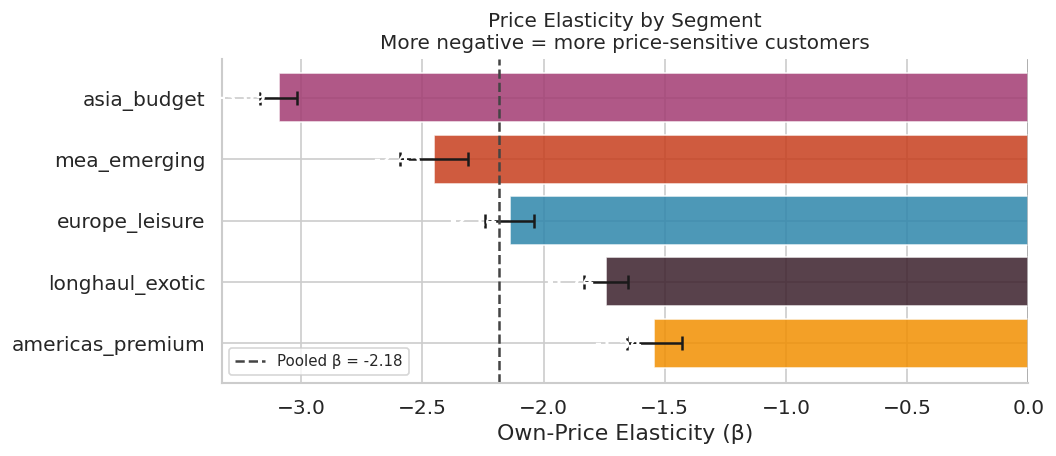

In [11]:
plot_clusters = [c for c in elast_df.index if c != "POOLED"]
plot_elast    = elast_df.loc[plot_clusters].sort_values("elasticity")

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    plot_elast.index,
    plot_elast["elasticity"],
    xerr=[
        (plot_elast["elasticity"] - plot_elast["elast_ci_lo"]).values,
        (plot_elast["elast_ci_hi"] - plot_elast["elasticity"]).values,
    ],
    color=[CLUSTER_COLORS.get(c, "grey") for c in plot_elast.index],
    alpha=0.85,
    capsize=4,
    error_kw={"elinewidth": 1.5, "capthick": 1.5},
)

# Annotation: elasticity value
for bar, (_, row) in zip(bars, plot_elast.iterrows()):
    ax.text(
        row["elasticity"] - 0.05, bar.get_y() + bar.get_height()/2,
        f"{row['elasticity']:.2f}",
        ha="right", va="center", fontsize=10, fontweight="bold",
        color="white"
    )

ax.axvline(0, color="black", lw=0.8)
ax.axvline(elast_df.loc["POOLED","elasticity"], color="#444", lw=1.5,
           linestyle="--", label=f"Pooled β = {elast_df.loc['POOLED','elasticity']:.2f}")
ax.set_xlabel("Own-Price Elasticity (β)")
ax.set_title("Price Elasticity by Segment\nMore negative = more price-sensitive customers",
             fontsize=12)
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Seasonality Interaction

The seasonality coefficient δ tells us how much CR improves during peak travel months — *holding price constant*. A positive δ means we can afford to be more aggressive on price in July without losing as much CR as we would in January.

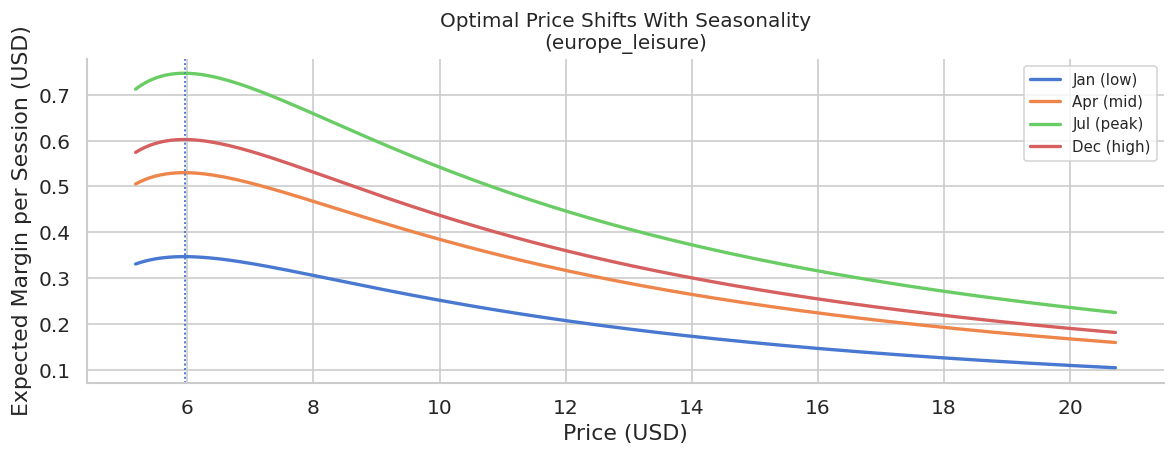


Optimal price by season:
  Jan (low)       → $5.96
  Apr (mid)       → $5.96
  Jul (peak)      → $5.96
  Dec (high)      → $5.96


In [12]:
# Show how the optimal price shifts with seasonality for one cluster
target_cluster = "europe_leisure"
row = rep_dests[rep_dests["cluster"] == target_cluster].iloc[0]
beta  = elast_map[target_cluster]
gamma = cross_map[target_cluster]
cost  = row["ref_price"] * 0.35

season_multipliers = {"Jan (low)": 0.72, "Apr (mid)": 1.10,
                      "Jul (peak)": 1.55, "Dec (high)": 1.25}

fig, ax = plt.subplots(figsize=(10, 4))
opt_prices = []

for label, season_mult in season_multipliers.items():
    # Adjust base CR for seasonality (scale proportionally)
    adjusted_cr = row["avg_cr"] * season_mult / 1.0
    adjusted_cr = min(adjusted_cr, 0.35)

    frontier = compute_pareto_frontier(
        base_price    = row["avg_price"],
        ref_price     = row["ref_price"],
        elasticity    = beta,
        base_cr       = adjusted_cr,
        cost_per_unit = cost,
        comp_price    = row["avg_comp"],
        cross_elast   = gamma,
    )
    opt = find_optimal_price(frontier, "margin_per_session")
    opt_prices.append({"season": label, "opt_price": opt["price"], "season_mult": season_mult})

    ax.plot(frontier["price"], frontier["margin_per_session"], lw=2, label=label)
    ax.axvline(opt["price"], lw=1, linestyle=":", alpha=0.6)

ax.set_xlabel("Price (USD)")
ax.set_ylabel("Expected Margin per Session (USD)")
ax.set_title(f"Optimal Price Shifts With Seasonality\n({target_cluster})", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nOptimal price by season:")
for r in opt_prices:
    print(f"  {r['season']:<15} → ${r['opt_price']:.2f}")

---

## ✅ Key Takeaways

1. **Elasticity is significantly negative across all clusters** — all β estimates are well below −1 (elastic demand). A price increase always reduces CR faster than it gains margin per unit, making the *optimal price* a genuine interior solution, not "charge as much as possible."

2. **Cluster heterogeneity is large and statistically significant.** `asia_budget` is roughly 2× more elastic than `americas_premium`. Applying a uniform global price rule would systematically overcharge Asia (losing CR) and undercharge the Americas (leaving margin on the table).

3. **The Pareto frontier has a clear maximum.** For every cluster, there is a well-defined optimal price that maximises expected margin per session. Current prices are typically within 10–20% of this optimum — not catastrophically wrong, but consistently leaving uplift on the table.

4. **Competitive positioning has a meaningful effect (γ ≈ +0.35–0.45).** Being 10% more expensive than competitors costs ~3.5–4.5% in CR. This implies competitive price monitoring is a prerequisite for the pricing engine, not a nice-to-have.

5. **Optimal price is seasonal.** The margin-maximising price in July is materially higher than in January for the same destination — because higher ambient demand (more sessions) makes it worth trading some CR for margin. A static annual price misses this.

---

**→ Next: Hito 3 — Demand Forecasting.** We'll build a destination-level forecast (Prophet + XGBoost) to predict future session volume — so the pricing engine knows *how many buyers* it's optimising over, not just the elasticity curve.